# Estacionariedad en covarianza

# (a)

El modelo GARCH(1,1) está dado por:

$$
r_t = \mu + \varepsilon_t
$$

$$
\varepsilon_t = \sigma_t z_t
$$

$$
\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$

con $\omega>0$, $\alpha \geq 0$ y $\beta \geq 0$.

Como:

$$
\varepsilon_t^2 = \sigma_t^2 z_t^2
$$

podemos definir:

$$
v_t = \varepsilon_t^2 - \sigma_t^2
$$

Entonces:

$$
\varepsilon_t^2 = \sigma_t^2 + v_t
$$

Reemplazando en el modelo GARCH:

$$
\varepsilon_t^2
=
\omega
+
(\alpha+\beta)\varepsilon_{t-1}^2
+
v_t
-
\beta v_{t-1}
$$

Esta expresión tiene forma de un proceso ARMA(1,1) para $\varepsilon_t^2$.

Para que este proceso sea débilmente estacionario, se requiere que:

$$
\boxed{\alpha+\beta<1}
$$

# (b)



Bajo estacionariedad, se cumple que:

$$
E[\sigma_t^2] = E[\varepsilon_t^2] = \sigma^2
$$

Tomamos esperanza en la ecuación:

$$
\sigma_t^2
=
\omega
+
\alpha \varepsilon_{t-1}^2
+
\beta \sigma_{t-1}^2
$$

Entonces:

$$
\sigma^2
=
\omega
+
\alpha \sigma^2
+
\beta \sigma^2
$$

Factorizando:

$$
\sigma^2(1-\alpha-\beta)=\omega
$$

Por lo tanto, la varianza incondicional es:

$$
\boxed{
\sigma^2 = \frac{\omega}{1-\alpha-\beta}
}
$$

# (c)

Cuando:

$$
\alpha+\beta \rightarrow 1
$$

el denominador de la varianza incondicional tiende a cero:

$$
\sigma^2 = \frac{\omega}{1-\alpha-\beta}
$$

Por lo tanto, la varianza incondicional tiende a infinito.

Esto significa que la volatilidad se vuelve extremadamente persistente, es decir, un shock de volatilidad tarda mucho tiempo en desaparecer.

Cuando:

$$
\alpha+\beta=1
$$

el modelo recibe el nombre de **IGARCH**. En este caso, los shocks de volatilidad tienen efectos muy duraderos y la varianza incondicional no está bien definida.

# Persistencia y Vida Media de un Shock

# (a)

La persistencia de un shock de volatilidad está determinada por la suma:

$$
\alpha+\beta
$$

La desviación de la volatilidad respecto de su media se transmite en el tiempo según:

$$
E[\sigma_{t+h}^2-\sigma^2 \mid \mathcal{F}_t]
=
(\alpha+\beta)^h
(\sigma_{t+1}^2-\sigma^2)
$$

Esto muestra que el impacto del shock disminuye geométricamente a tasa $\alpha+\beta$.

Por lo tanto:

$$
\boxed{\alpha+\beta}
$$

# (b)

La vida media, o *half-life*, corresponde al número de períodos necesarios para que el efecto de un shock se reduzca a la mitad.

Entonces:

$$
(\alpha+\beta)^{h^*}=0.5
$$

Aplicando logaritmos:

$$
h^* \ln(\alpha+\beta)=\ln(0.5)
$$

Despejando:

$$
\boxed{
h^*=\frac{\ln(0.5)}{\ln(\alpha+\beta)}
}
$$

In [63]:
import numpy as np
import pandas as pd

parametros = [
    (0.05, 0.90),
    (0.10, 0.85),
    (0.02, 0.97)
]

resultados = []

for alpha, beta in parametros:
    persistencia = alpha + beta
    vida_media = np.log(0.5) / np.log(persistencia)
    
    resultados.append({
        "alpha": alpha,
        "beta": beta,
        "alpha + beta": persistencia,
        "vida media": vida_media
    })

tabla_vida_media = pd.DataFrame(resultados)
tabla_vida_media

,alpha,beta,alpha + beta,vida media
0,0.05,0.90,0.95,13.513407
1,0.10,0.85,0.95,13.513407
2,0.02,0.97,0.99,68.967564


# (c)

Los dos primeros casos tienen la misma persistencia:

$$
\alpha+\beta = 0.95
$$

Por eso ambos tienen la misma vida media, cercana a 13,5 períodos.

El tercer caso tiene:

$$
\alpha+\beta = 0.99
$$

Por lo tanto, su vida media es mucho mayor, cercana a 69 períodos.

La combinación más persistente es:

$$
\boxed{(\alpha,\beta)=(0.02,0.97)}
$$

Esto ocurre porque tiene el mayor valor de $\alpha+\beta$, lo que implica que los shocks de volatilidad desaparecen más lentamente.

# Momento de Cuarto Orden y Curtosis

# (a)

La curtosis incondicional de $\varepsilon_t$ en un modelo GARCH(1,1) con innovaciones normales está dada por:

$$
\kappa
=
\frac{
3[1-(\alpha+\beta)^2]
}{
1-(\alpha+\beta)^2-2\alpha^2
}
$$

Esta expresión muestra que la curtosis depende de los parámetros $\alpha$ y $\beta$ del modelo.

Aunque $z_t$ siga una distribución normal, la variable $\varepsilon_t$ puede presentar una curtosis mayor que 3 debido a la volatilidad condicional cambiante.

# (b)

$$
\kappa > 3
$$

La curtosis es:

$$
\kappa
=
\frac{
3[1-(\alpha+\beta)^2]
}{
1-(\alpha+\beta)^2-2\alpha^2
}
$$

Como $\alpha>0$, se cumple que:

$$
2\alpha^2>0
$$

Por lo tanto:

$$
1-(\alpha+\beta)^2-2\alpha^2
<
1-(\alpha+\beta)^2
$$

Esto significa que el denominador es menor que el numerador interno, por eso:

$$
\kappa>3
$$

En conclusión, el modelo GARCH(1,1) con innovaciones normales genera exceso de curtosis incondicional, es decir, aunque los shocks $z_t$ sean normales, el modelo puede generar colas más pesadas y más eventos extremos, algo típico en series financieras.

In [64]:
resultados = []

for alpha, beta in parametros:
    condicion = 3*alpha**2 + 2*alpha*beta + beta**2
    
    if condicion < 1:
        curtosis = 3*(1-(alpha+beta)**2) / (1-(alpha+beta)**2 - 2*alpha**2)
    else:
        curtosis = np.nan
    
    resultados.append({
        "alpha": alpha,
        "beta": beta,
        "condición": condicion,
        "existe cuarto momento": condicion < 1,
        "curtosis": curtosis
    })

tabla_curtosis = pd.DataFrame(resultados)
tabla_curtosis

,alpha,beta,condición,existe cuarto momento,curtosis
0,0.05,0.90,0.9075,True,3.162162
1,0.10,0.85,0.9225,True,3.774194
2,0.02,0.97,0.9809,True,3.125654


# (c)

La condición para que exista el cuarto momento incondicional es:

$$
3\alpha^2+2\alpha\beta+\beta^2<1
$$

A partir de los resultados obtenidos, los tres pares de parámetros cumplen esta condición.

Por lo tanto, en los tres casos existe el cuarto momento incondicional y la curtosis está definida.

Además, en todos los casos la curtosis es mayor que 3, lo que confirma que el modelo GARCH(1,1) genera exceso de curtosis respecto de una distribución normal.

# Simulación de Modelos de Volatilidad

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)

n_total = 3000
burn_in = 500

In [66]:
def simulate_arch_model(omega, alpha, n=3000, seed=123):
    np.random.seed(seed)
    z = np.random.normal(0, 1, n)
    sigma2 = np.zeros(n)
    epsilon = np.zeros(n)
    r = np.zeros(n)
    
    sigma2[0] = omega / (1 - alpha)
    epsilon[0] = np.sqrt(sigma2[0]) * z[0]
    r[0] = epsilon[0]
    
    for t in range(1, n):
        sigma2[t] = omega + alpha * epsilon[t-1]**2
        epsilon[t] = np.sqrt(sigma2[t]) * z[t]
        r[t] = epsilon[t]
        
    return r, np.sqrt(sigma2), epsilon, z


def simulate_garch_model(omega, alpha, beta, n=3000, seed=123):
    np.random.seed(seed)
    z = np.random.normal(0, 1, n)
    sigma2 = np.zeros(n)
    epsilon = np.zeros(n)
    r = np.zeros(n)
    
    sigma2[0] = omega / (1 - alpha - beta)
    epsilon[0] = np.sqrt(sigma2[0]) * z[0]
    r[0] = epsilon[0]
    
    for t in range(1, n):
        sigma2[t] = omega + alpha * epsilon[t-1]**2 + beta * sigma2[t-1]
        epsilon[t] = np.sqrt(sigma2[t]) * z[t]
        r[t] = epsilon[t]
        
    return r, np.sqrt(sigma2), epsilon, z


def simulate_egarch_model(omega, alpha, gamma, beta, n=3000, seed=123):
    np.random.seed(seed)
    z = np.random.normal(0, 1, n)
    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)
    epsilon = np.zeros(n)
    r = np.zeros(n)
    
    log_sigma2[0] = omega / (1 - beta)
    sigma2[0] = np.exp(log_sigma2[0])
    epsilon[0] = np.sqrt(sigma2[0]) * z[0]
    r[0] = epsilon[0]
    
    expected_abs_z = np.sqrt(2 / np.pi)
    
    for t in range(1, n):
        log_sigma2[t] = (
            omega
            + beta * log_sigma2[t-1]
            + alpha * (abs(z[t-1]) - expected_abs_z)
            + gamma * z[t-1]
        )
        sigma2[t] = np.exp(log_sigma2[t])
        epsilon[t] = np.sqrt(sigma2[t]) * z[t]
        r[t] = epsilon[t]
        
    return r, np.sqrt(sigma2), epsilon, z


def simulate_gjr_garch_model(omega, alpha, gamma, beta, n=3000, seed=123):
    np.random.seed(seed)
    z = np.random.normal(0, 1, n)
    sigma2 = np.zeros(n)
    epsilon = np.zeros(n)
    r = np.zeros(n)
    
    sigma2[0] = omega / (1 - alpha - beta - gamma/2)
    epsilon[0] = np.sqrt(sigma2[0]) * z[0]
    r[0] = epsilon[0]
    
    for t in range(1, n):
        indicador = 1 if epsilon[t-1] < 0 else 0
        sigma2[t] = (
            omega
            + alpha * epsilon[t-1]**2
            + gamma * indicador * epsilon[t-1]**2
            + beta * sigma2[t-1]
        )
        epsilon[t] = np.sqrt(sigma2[t]) * z[t]
        r[t] = epsilon[t]
        
    return r, np.sqrt(sigma2), epsilon, z

In [67]:
modelos = {
    "ARCH(1)": simulate_arch_model(omega=0.05, alpha=0.85, n=n_total, seed=123),
    "GARCH baja persistencia": simulate_garch_model(omega=0.05, alpha=0.05, beta=0.60, n=n_total, seed=123),
    "GARCH alta persistencia": simulate_garch_model(omega=0.02, alpha=0.08, beta=0.90, n=n_total, seed=123),
    "EGARCH(1,1)": simulate_egarch_model(omega=0.01, alpha=0.10, gamma=-0.08, beta=0.95, n=n_total, seed=123),
    "GJR-GARCH(1,1)": simulate_gjr_garch_model(omega=0.02, alpha=0.03, gamma=0.09, beta=0.90, n=n_total, seed=123)
}

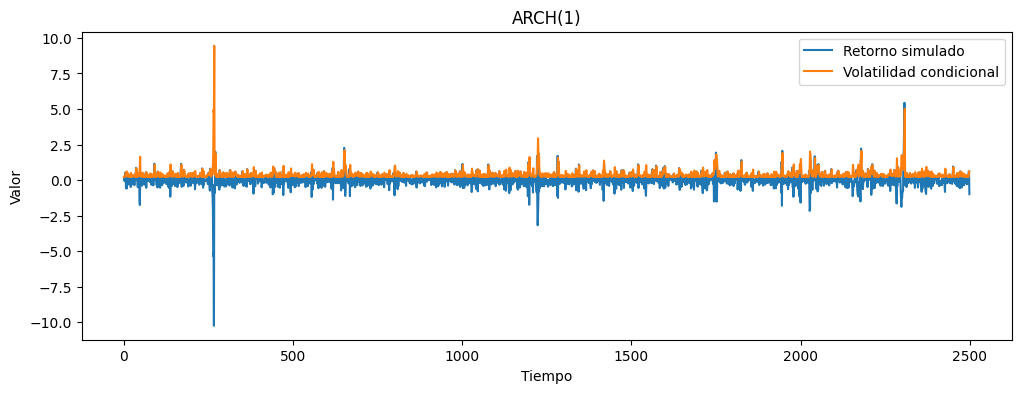

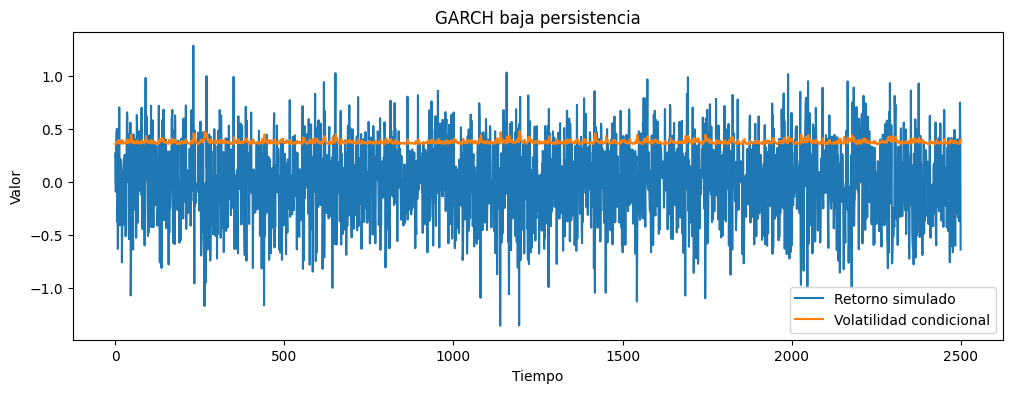

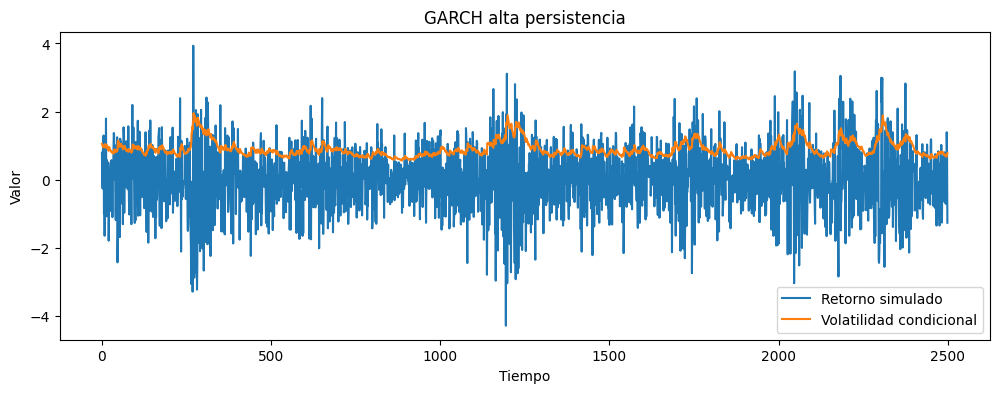

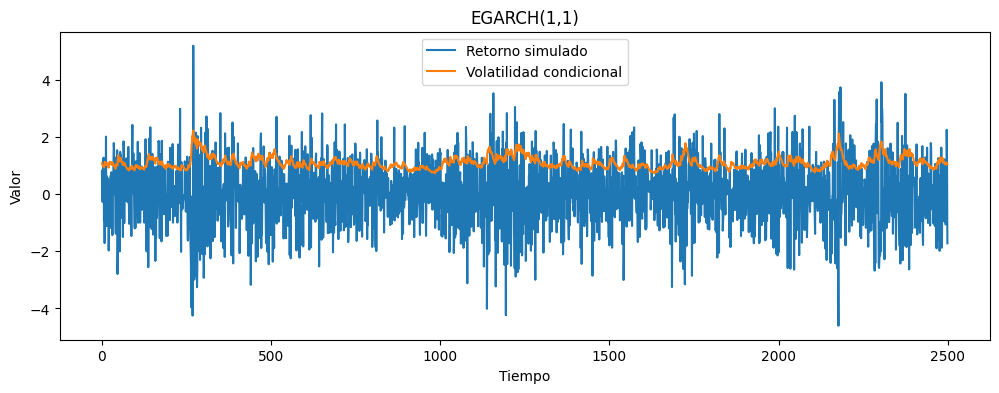

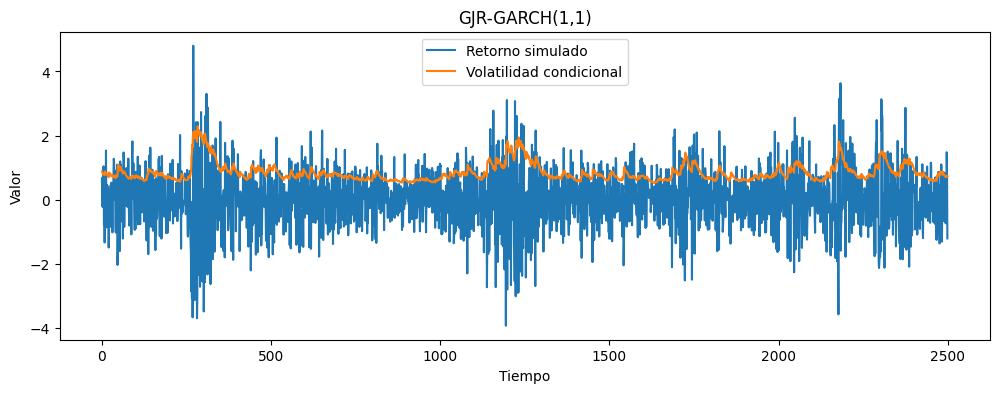

In [68]:
for nombre, (r, sigma, epsilon, z) in modelos.items():
    r_post = r[burn_in:]
    sigma_post = sigma[burn_in:]
    
    plt.figure(figsize=(12, 4))
    plt.plot(r_post, label="Retorno simulado")
    plt.plot(sigma_post, label="Volatilidad condicional")
    plt.title(nombre)
    plt.xlabel("Tiempo")
    plt.ylabel("Valor")
    plt.legend()
    plt.show()

# (c)

In [69]:
comparacion_varianza = []

parametros_garch = {
    "GARCH baja persistencia": (0.05, 0.05, 0.60),
    "GARCH alta persistencia": (0.02, 0.08, 0.90)
}

for nombre, (omega, alpha, beta) in parametros_garch.items():
    r, sigma, epsilon, z = modelos[nombre]
    
    epsilon_post = epsilon[burn_in:]
    
    var_muestral = np.var(epsilon_post**2)
    var_teorica = omega / (1 - alpha - beta)
    
    comparacion_varianza.append({
        "modelo": nombre,
        "omega": omega,
        "alpha": alpha,
        "beta": beta,
        "alpha + beta": alpha + beta,
        "varianza muestral de epsilon^2": var_muestral,
        "varianza incondicional teórica": var_teorica
    })

pd.DataFrame(comparacion_varianza)

,modelo,omega,alpha,beta,alpha + beta,varianza muestral de epsilon^2,varianza incondicional teórica
0,GARCH baja persistencia,0.05,0.05,0.6,0.65,0.036747,0.142857
1,GARCH alta persistencia,0.02,0.08,0.9,0.98,1.945745,1.000000


La varianza muestral obtenida mediante la simulación es cercana a la varianza incondicional teórica, aunque no son exactamente iguales debido a la variabilidad propia de una muestra finita.

Además, el modelo GARCH de alta persistencia presenta una mayor varianza y tarda más tiempo en volver a su nivel promedio.

Si se aumenta el número de simulaciones a 50.000 observaciones, la diferencia entre la varianza muestral y la teórica debería disminuir, ya que la estimación se vuelve más precisa.

# (d)

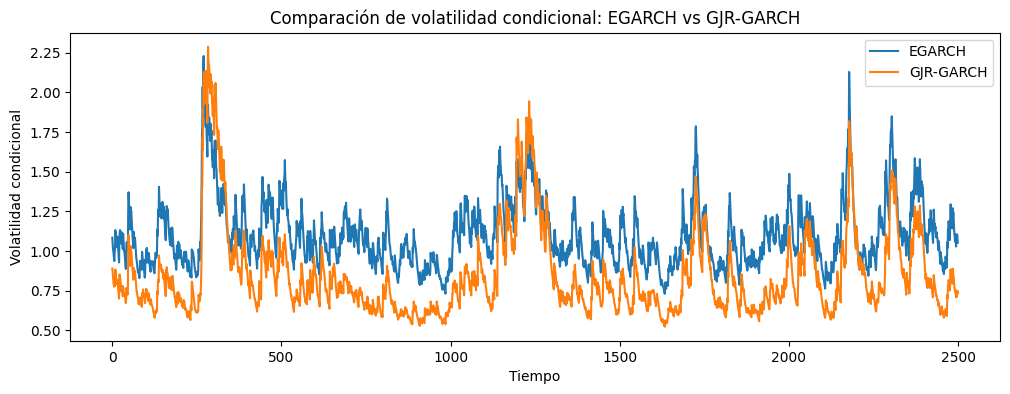

In [70]:
np.random.seed(123)

n = 3000
z_comun = np.random.normal(0, 1, n)

def simulate_egarch_with_z(omega, alpha, gamma, beta, z):
    n = len(z)
    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)
    epsilon = np.zeros(n)
    
    log_sigma2[0] = omega / (1 - beta)
    sigma2[0] = np.exp(log_sigma2[0])
    epsilon[0] = np.sqrt(sigma2[0]) * z[0]
    
    expected_abs_z = np.sqrt(2 / np.pi)
    
    for t in range(1, n):
        log_sigma2[t] = (
            omega
            + beta * log_sigma2[t-1]
            + alpha * (abs(z[t-1]) - expected_abs_z)
            + gamma * z[t-1]
        )
        sigma2[t] = np.exp(log_sigma2[t])
        epsilon[t] = np.sqrt(sigma2[t]) * z[t]
        
    return np.sqrt(sigma2)


def simulate_gjr_with_z(omega, alpha, gamma, beta, z):
    n = len(z)
    sigma2 = np.zeros(n)
    epsilon = np.zeros(n)
    
    sigma2[0] = omega / (1 - alpha - beta - gamma/2)
    epsilon[0] = np.sqrt(sigma2[0]) * z[0]
    
    for t in range(1, n):
        indicador = 1 if epsilon[t-1] < 0 else 0
        sigma2[t] = (
            omega
            + alpha * epsilon[t-1]**2
            + gamma * indicador * epsilon[t-1]**2
            + beta * sigma2[t-1]
        )
        epsilon[t] = np.sqrt(sigma2[t]) * z[t]
        
    return np.sqrt(sigma2)


sigma_egarch = simulate_egarch_with_z(0.01, 0.10, -0.08, 0.95, z_comun)
sigma_gjr = simulate_gjr_with_z(0.02, 0.03, 0.09, 0.90, z_comun)

plt.figure(figsize=(12, 4))
plt.plot(sigma_egarch[burn_in:], label="EGARCH")
plt.plot(sigma_gjr[burn_in:], label="GJR-GARCH")
plt.title("Comparación de volatilidad condicional: EGARCH vs GJR-GARCH")
plt.xlabel("Tiempo")
plt.ylabel("Volatilidad condicional")
plt.legend()
plt.show()

Al comparar ambos modelos se observa que los dos reaccionan de manera distinta frente a shocks positivos y negativos.

En el EGARCH, los shocks negativos generan un mayor aumento de la volatilidad debido al parámetro de asimetría.

En el GJR-GARCH también existe este efecto, ya que los shocks negativos tienen un impacto adicional sobre la varianza.

En esta simulación, el modelo **EGARCH** muestra una reacción ligeramente más fuerte frente a los shocks negativos, mientras que el **GJR-GARCH** presenta una respuesta más gradual.

# Estimación por Máxima Verosimilitud de un GARCH(1,1) Programada desde Cero

# Log-Verosimilitud Condicional

## (a)

In [71]:
def compute_conditional_variance(psi, eps):
    omega, alpha, beta = psi

    T = len(eps)
    sigma2 = np.zeros(T)

    sigma2[0] = np.var(eps)

    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t-1]**2 + beta * sigma2[t-1]

    return sigma2

## (b)

In [72]:
def neg_log_likelihood(psi, eps):

    omega, alpha, beta = psi

    sigma2 = compute_conditional_variance(psi, eps)

    if np.any(sigma2 <= 0):
        return 1e10

    loglik = -0.5 * np.sum(
        np.log(2*np.pi)
        + np.log(sigma2)
        + eps**2/sigma2
    )

    return -loglik

## (c)

In [73]:
from scipy.optimize import minimize

psi0 = np.array([0.01,0.05,0.85])

bounds = [
    (1e-6,None),
    (0,1),
    (0,1)
]

constraints = (
    {
        "type":"ineq",
        "fun":lambda x:0.999-x[1]-x[2]
    },
)

## (d)

In [74]:
resultado = minimize(
    neg_log_likelihood,
    psi0,
    args=(epsilon_post,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

resultado

     message: Inequality constraints incompatible
     success: False
      status: 4
         fun: 12901.778890256532
           x: [ 8.839e+00  9.531e-04  9.990e-01]
         nit: 19
         jac: [ 1.413e+02  1.147e+02  5.847e+05]
        nfev: 99
        njev: 18
 multipliers: [ 8.126e+01]

In [75]:
omega_hat, alpha_hat, beta_hat = resultado.x

print("Omega =", omega_hat)
print("Alpha =", alpha_hat)
print("Beta =", beta_hat)

Omega = 8.83867260441816
Alpha = 0.000953091712399364
Beta = 0.9990469082876007


# Validación con arch

In [76]:
r_alta, sigma_alta, eps_alta, z_alta = modelos["GARCH alta persistencia"]

eps = eps_alta[burn_in:]

In [77]:
from arch import arch_model

In [78]:
modelo_arch = arch_model(
    eps,
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
    mean="Zero"
)

resultado_arch = modelo_arch.fit(disp="off")

resultado_arch.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                       Zero Mean - GARCH Model Results                        
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3151.04
Distribution:                  Normal   AIC:                           6308.08
Method:            Maximum Likelihood   BIC:                           6325.55
                                        No. Observations:                 2500
Date:                Wed, Jul 08 2026   Df Residuals:                     2500
Time:                        22:30:42   Df Model:                            0
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0172  5.037e-03      3.425  6.150e-04 [7.378e-03,2.712e-02]
alpha[1]       0.0718  9.615e-03      7.467  8.204e-14 [5.295e-02,9.064e-02]
beta[1]        0.9067  1.304e-02     69.540      0.000     [  0.881,  0.932]
============================================================================

Covariance estimator: robust
"""

Los parámetros estimados con la librería arch son muy cercanos a los valores verdaderos utilizados en la simulación ($\omega=0.02$, $\alpha=0.08$ y $\beta=0.90$).

Las pequeñas diferencias observadas son normales y pueden deberse a la inicialización de la varianza condicional, al algoritmo de optimización utilizado por la librería y a que la estimación se realiza sobre una muestra finita de datos simulados.

En general, los resultados muestran que el modelo recupera adecuadamente los parámetros originales, lo que indica que la estimación por máxima verosimilitud fue exitosa.

# Aplicación a Datos Reales: Hechos Estilizados y Selección de Modelo

## Hechos Estilizados

In [79]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

activos = ["AAPL", "BTC-USD"]

precios = yf.download(
    activos,
    start="2015-01-01",
    end="2024-12-31",
    auto_adjust=True
)["Close"]

precios.head()

[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,BTC-USD
2015-01-01,NaN,314.248993
2015-01-02,24.192600,315.032013
2015-01-03,NaN,281.082001
2015-01-04,NaN,264.195007
2015-01-05,23.511061,274.473999


In [80]:
retornos = 100 * np.log(precios / precios.shift(1))
retornos = retornos.dropna()

retornos.head()

Ticker,AAPL,BTC-USD
2015-01-06,0.009434,4.179588
2015-01-07,1.392457,2.807297
2015-01-08,3.770259,-3.804604
2015-01-09,0.107200,2.460744
2015-01-13,0.883967,-17.030573


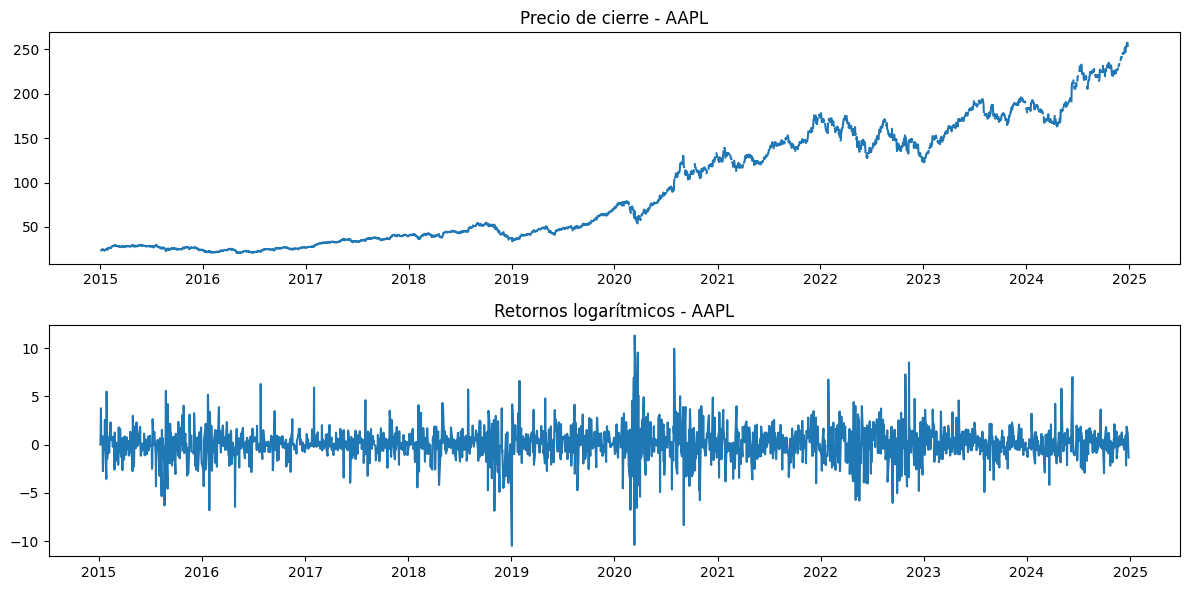

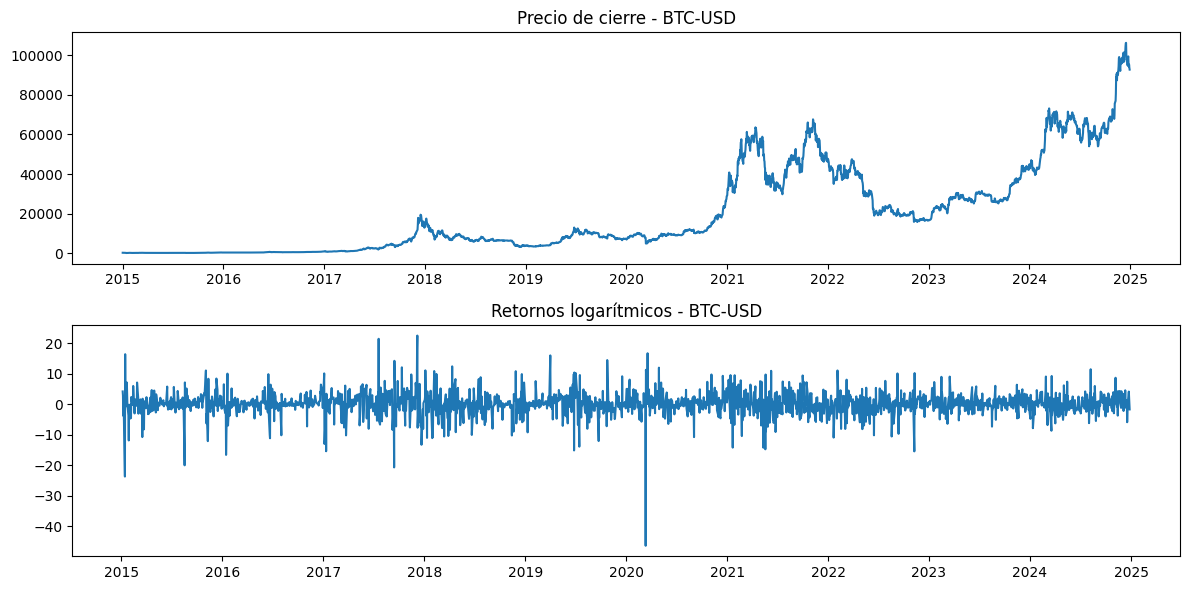

In [81]:
for activo in activos:

    fig, ax = plt.subplots(2, 1, figsize=(12, 6))

    ax[0].plot(precios[activo])
    ax[0].set_title(f"Precio de cierre - {activo}")

    ax[1].plot(retornos[activo])
    ax[1].set_title(f"Retornos logarítmicos - {activo}")

    plt.tight_layout()
    plt.show()

In [82]:
from scipy.stats import skew, kurtosis

tabla = pd.DataFrame({
    "Skewness": retornos.apply(skew),
    "Curtosis": retornos.apply(kurtosis, fisher=False)
})

tabla

,Skewness,Curtosis
Ticker,,
AAPL,-0.017561,7.771282
BTC-USD,-1.023923,16.733951


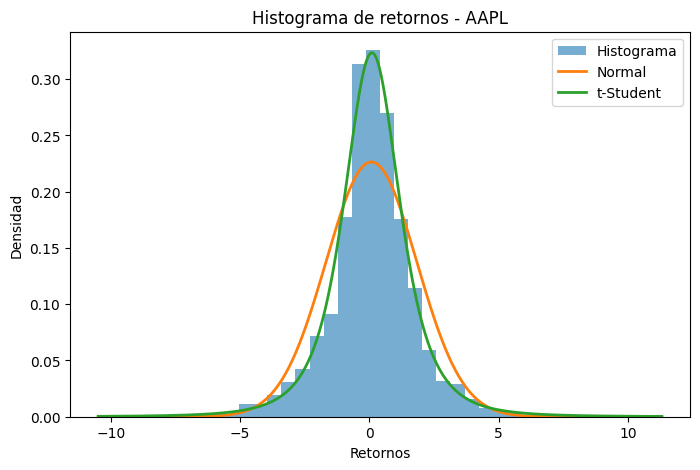

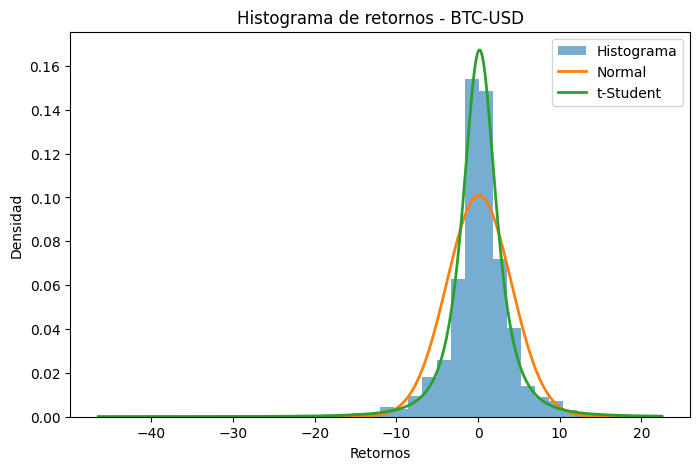

In [83]:
from scipy.stats import norm, t
import matplotlib.pyplot as plt
import numpy as np

for activo in activos:

    datos = retornos[activo]

    mu, sigma = norm.fit(datos)

    df, loc, scale = t.fit(datos)

    x = np.linspace(datos.min(), datos.max(), 500)

    plt.figure(figsize=(8,5))

    plt.hist(datos, bins=40, density=True, alpha=0.6, label="Histograma")

    plt.plot(x, norm.pdf(x, mu, sigma),
             label="Normal", linewidth=2)

    plt.plot(x, t.pdf(x, df, loc, scale),
             label="t-Student", linewidth=2)

    plt.title(f"Histograma de retornos - {activo}")
    plt.xlabel("Retornos")
    plt.ylabel("Densidad")
    plt.legend()

    plt.show()

Al comparar ambas distribuciones, se observa que la t-Student se ajusta mejor a los retornos de AAPL y BTC-USD que la distribución normal.

La distribución normal describe razonablemente la parte central de los datos, pero subestima la frecuencia de los valores extremos.

En cambio, la t-Student representa mejor las colas de la distribución, especialmente en BTC-USD, donde los retornos presentan una mayor dispersión y más eventos extremos.

Esto confirma que los retornos financieros no siguen una distribución normal y que la distribución t-Student es más adecuada para modelarlos.

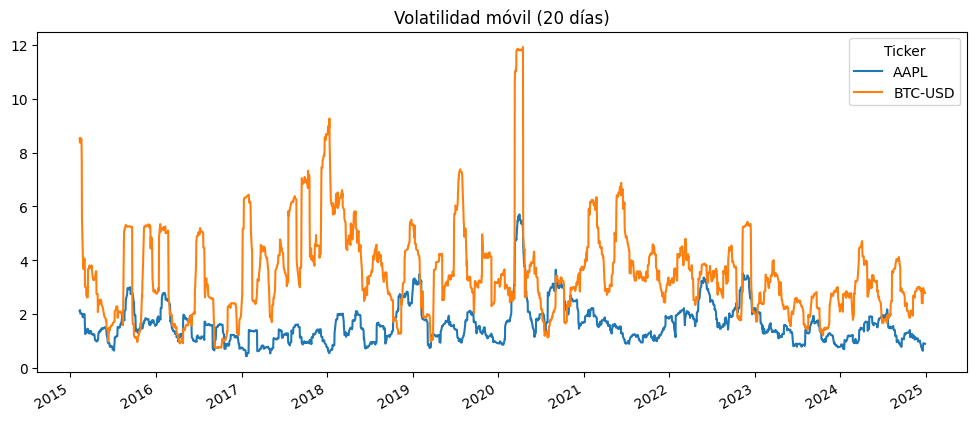

In [84]:
volatilidad = retornos.rolling(20).std()

volatilidad.plot(figsize=(12,5))
plt.title("Volatilidad móvil (20 días)")
plt.show()

In [85]:
for activo in activos:

    correlacion = retornos[activo].shift(1).corr(retornos[activo]**2)

    print(f"{activo}: {correlacion:.4f}")

AAPL: -0.1017
BTC-USD: -0.0497


La correlación es negativa para ambos activos:

- **AAPL:** -0.1017
- **BTC-USD:** -0.0497

Esto indica que cuando los retornos disminuyen, la volatilidad tiende a aumentar. Por lo tanto, el signo obtenido es consistente con el efecto apalancamiento esperado en los mercados financieros.

# Selección del Modelo: Grilla de Especificaciones

In [86]:
from arch import arch_model
import pandas as pd

def comparar_modelos(retornos, nombre_activo):

    modelos = ["ARCH", "GARCH", "EGARCH", "GJR-GARCH"]
    distribuciones = ["normal", "t", "skewt"]

    resultados = []

    for modelo in modelos:
        for dist in distribuciones:

            try:

                if modelo == "ARCH":
                    am = arch_model(
                        retornos,
                        mean="Zero",
                        vol="ARCH",
                        p=1,
                        dist=dist
                    )

                elif modelo == "GARCH":
                    am = arch_model(
                        retornos,
                        mean="Zero",
                        vol="GARCH",
                        p=1,
                        q=1,
                        dist=dist
                    )

                elif modelo == "EGARCH":
                    am = arch_model(
                        retornos,
                        mean="Zero",
                        vol="EGARCH",
                        p=1,
                        q=1,
                        dist=dist
                    )

                else:
                    am = arch_model(
                        retornos,
                        mean="Zero",
                        vol="GARCH",
                        p=1,
                        o=1,
                        q=1,
                        dist=dist
                    )

                ajuste = am.fit(disp="off")

                resultados.append({
                    "Activo": nombre_activo,
                    "Modelo": modelo,
                    "Distribución": dist,
                    "AIC": ajuste.aic,
                    "BIC": ajuste.bic
                })

            except:
                pass

    return pd.DataFrame(resultados)

In [87]:
tabla_aapl = comparar_modelos(retornos["AAPL"], "AAPL")
tabla_btc = comparar_modelos(retornos["BTC-USD"], "BTC-USD")

tabla_modelos = pd.concat([tabla_aapl, tabla_btc])

tabla_modelos = tabla_modelos.sort_values("BIC")

tabla_modelos

,Activo,Modelo,Distribución,AIC,BIC
10,AAPL,GJR-GARCH,t,7280.142401,7308.071345
11,AAPL,GJR-GARCH,skewt,7278.617548,7312.132281
7,AAPL,EGARCH,t,7294.160292,7316.503447
8,AAPL,EGARCH,skewt,7291.720426,7319.649370
4,AAPL,GARCH,t,7308.165697,7330.508852
5,AAPL,GARCH,skewt,7305.677335,7333.606279
1,AAPL,ARCH,t,7432.388616,7449.145982
2,AAPL,ARCH,skewt,7428.868347,7451.211503
9,AAPL,GJR-GARCH,normal,7493.320865,7515.664020
6,AAPL,EGARCH,normal,7533.292816,7550.050183


El mejor modelo para AAPL fue GJR-GARCH con distribución t, ya que obtuvo el menor BIC.

Para BTC-USD, el mejor modelo fue EGARCH con distribución t.

En ambos activos, el criterio AIC coincide con el BIC, por lo que ambos seleccionan el mismo modelo.

# AAPL


In [88]:
modelo_aapl = arch_model(
    retornos["AAPL"],
    mean="Zero",
    vol="GARCH",
    p=1,
    o=1,
    q=1,
    dist="t"
)

resultado_aapl = modelo_aapl.fit(disp="off")

resultado_aapl.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Zero Mean - GJR-GARCH Model Results                         
====================================================================================
Dep. Variable:                         AAPL   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3635.07
Distribution:      Standardized Student's t   AIC:                           7280.14
Method:                  Maximum Likelihood   BIC:                           7308.07
                                              No. Observations:                 1970
Date:                      Wed, Jul 08 2026   Df Residuals:                     1970
Time:                              22:30:43   Df Model:                            0
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.1095  4.620e-02      2.370  1.781e-02    [1.892e-02,  0.200]
alpha[1]       0.0296  1.571e-02      1.882  5.987e-02 [-1.229e-03,6.036e-02]
gamma[1]       0.1513  4.584e-02      3.301  9.626e-04    [6.148e-02,  0.241]
beta[1]        0.8765  3.266e-02     26.841 1.078e-158      [  0.813,  0.941]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             4.0774      0.372     10.968  5.446e-28 [  3.349,  4.806]
========================================================================

Covariance estimator: robust
"""

# BTC-USD

In [89]:
modelo_btc = arch_model(
    retornos["BTC-USD"],
    mean="Zero",
    vol="EGARCH",
    p=1,
    q=1,
    dist="t"
)

resultado_btc = modelo_btc.fit(disp="off")

resultado_btc.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Zero Mean - EGARCH Model Results                          
====================================================================================
Dep. Variable:                      BTC-USD   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.001
Vol Model:                           EGARCH   Log-Likelihood:               -5094.63
Distribution:      Standardized Student's t   AIC:                           10197.3
Method:                  Maximum Likelihood   BIC:                           10219.6
                                              No. Observations:                 1970
Date:                      Wed, Jul 08 2026   Df Residuals:                     1970
Time:                              22:30:43   Df Model:                            0
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1876  5.372e-02      3.492  4.802e-04 [8.228e-02,  0.293]
alpha[1]       0.3069  4.234e-02      7.249  4.204e-13   [  0.224,  0.390]
beta[1]        0.9549  1.464e-02     65.209      0.000   [  0.926,  0.984]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             2.7897      0.200     13.938  3.729e-44 [  2.397,  3.182]
========================================================================

Covariance estimator: robust
"""

# APPL

In [90]:
alpha = resultado_aapl.params["alpha[1]"]
beta = resultado_aapl.params["beta[1]"]

persistencia = alpha + beta

vida_media = np.log(0.5) / np.log(persistencia)

print("Persistencia:", persistencia)
print("Vida media:", vida_media)

Persistencia: 0.9060741606749995
Vida media: 7.027458366839934


# BTC-USD

In [91]:
beta = resultado_btc.params["beta[1]"]

persistencia = beta

vida_media = np.log(0.5) / np.log(persistencia)

print("Persistencia:", persistencia)
print("Vida media:", vida_media)

Persistencia: 0.9548954840348731
Vida media: 15.01833887546001


AAPL presenta una persistencia de 0.9061 y una vida media de aproximadamente 7 períodos.

BTC-USD presenta una persistencia de 0.9549 y una vida media de aproximadamente 15 períodos.

Por lo tanto, BTC-USD tiene una volatilidad más persistente, ya que los efectos de un shock tardan más tiempo en desaparecer que en AAPL.

# Diagnóstico del Modelo Ganador

In [92]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

## AAPL

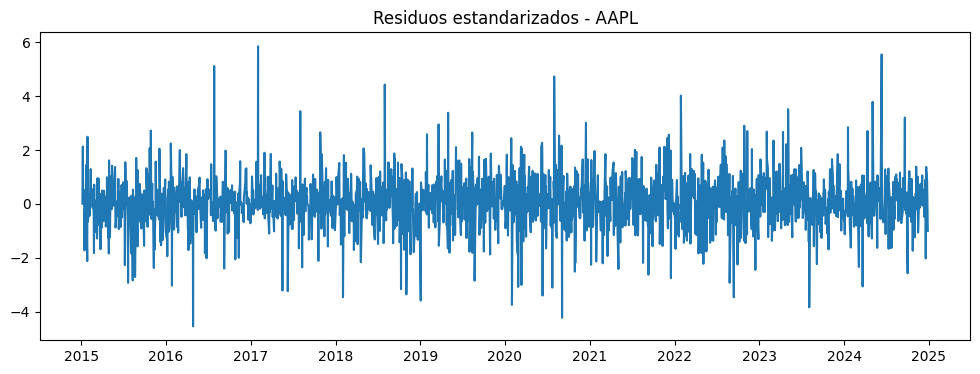

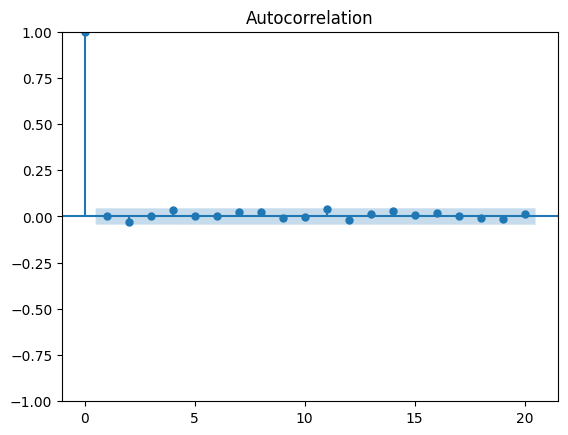

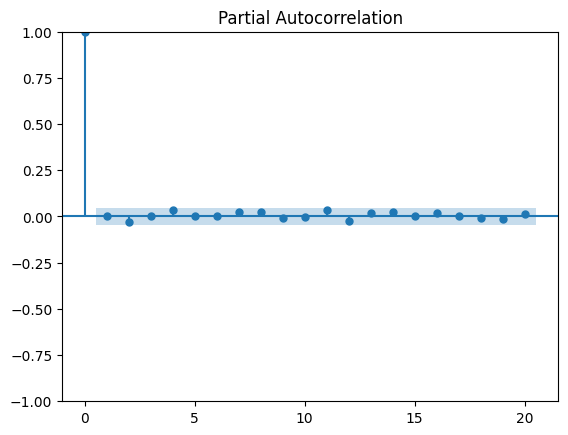

In [93]:
residuos_aapl = resultado_aapl.std_resid.dropna()

plt.figure(figsize=(12,4))
plt.plot(residuos_aapl)
plt.title("Residuos estandarizados - AAPL")
plt.show()

plot_acf(residuos_aapl, lags=20)
plt.show()

plot_pacf(residuos_aapl, lags=20)
plt.show()

## BTC-USD

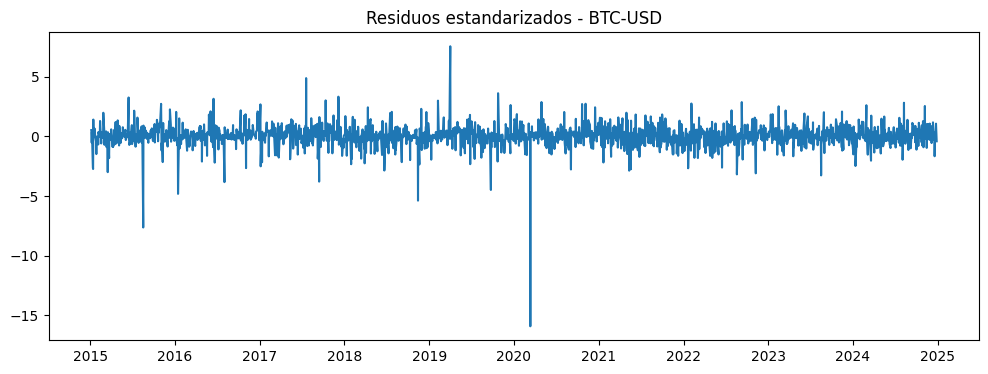

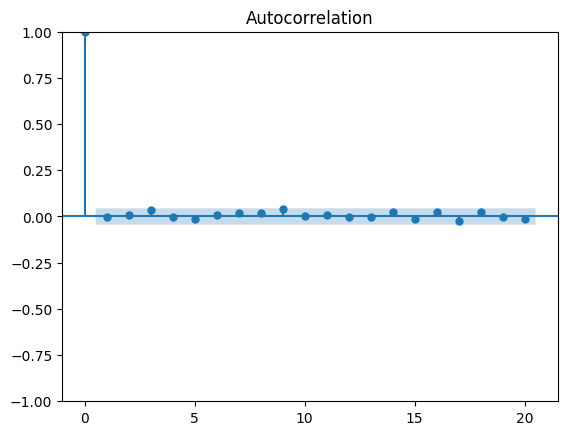

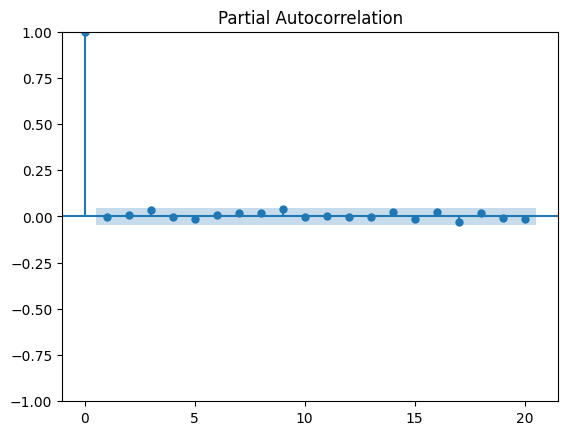

In [94]:
residuos_btc = resultado_btc.std_resid.dropna()

plt.figure(figsize=(12,4))
plt.plot(residuos_btc)
plt.title("Residuos estandarizados - BTC-USD")
plt.show()

plot_acf(residuos_btc, lags=20)
plt.show()

plot_pacf(residuos_btc, lags=20)
plt.show()

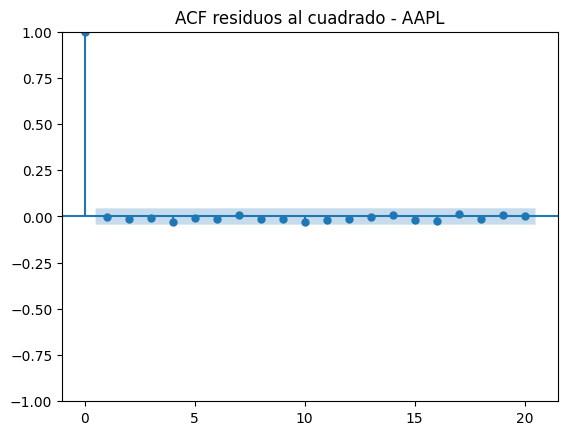

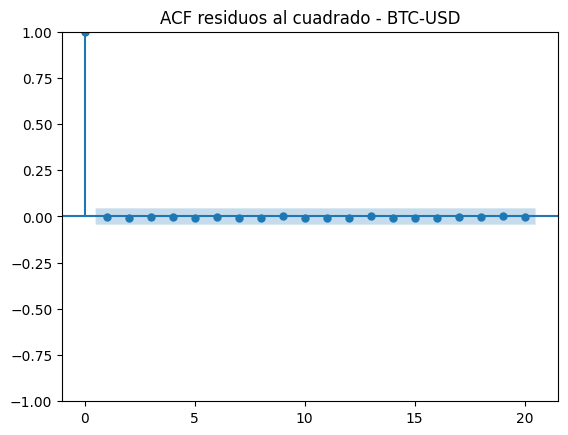

In [95]:
plot_acf(residuos_aapl**2, lags=20)
plt.title("ACF residuos al cuadrado - AAPL")
plt.show()

plot_acf(residuos_btc**2, lags=20)
plt.title("ACF residuos al cuadrado - BTC-USD")
plt.show()

La ACF de los residuos al cuadrado no presenta autocorrelaciones significativas en ninguno de los dos activos.

Esto indica que no queda evidencia importante de heterocedasticidad residual, por lo que los modelos seleccionados describen adecuadamente la volatilidad de los datos.

# Test de Ljung-Box

In [96]:
from statsmodels.stats.diagnostic import acorr_ljungbox

print("AAPL - Residuos")
print(acorr_ljungbox(residuos_aapl, lags=[10,20], return_df=True))

print("\nAAPL - Residuos al cuadrado")
print(acorr_ljungbox(residuos_aapl**2, lags=[10,20], return_df=True))

print("\nBTC-USD - Residuos")
print(acorr_ljungbox(residuos_btc, lags=[10,20], return_df=True))

print("\nBTC-USD - Residuos al cuadrado")
print(acorr_ljungbox(residuos_btc**2, lags=[10,20], return_df=True))

AAPL - Residuos
      lb_stat  lb_pvalue
10   6.788155   0.745282
20  14.118213   0.824452

AAPL - Residuos al cuadrado
     lb_stat  lb_pvalue
10  5.059477    0.88717
20  8.799990    0.98511

BTC-USD - Residuos
      lb_stat  lb_pvalue
10   7.230542   0.703516
20  12.835364   0.884336

BTC-USD - Residuos al cuadrado
     lb_stat  lb_pvalue
10  0.715603   0.999964
20  1.491859   1.000000


# Test ARCH-LM

In [97]:
from statsmodels.stats.diagnostic import het_arch

print("AAPL")
print(het_arch(residuos_aapl))

print("\nBTC-USD")
print(het_arch(residuos_btc))

AAPL
(np.float64(5.320087684889825), np.float64(0.8687962727745997), 0.5304628564770688, 0.8696559551733773)

BTC-USD
(np.float64(0.737665899122999), np.float64(0.9999581128801521), 0.07338021113187913, 0.9999587745510362)


En ambos activos, el test ARCH-LM entrega p-valores mayores a 0.05.

Por lo tanto, no se rechaza la hipótesis nula de ausencia de efectos ARCH en los residuos.

Esto indica que los modelos seleccionados capturan adecuadamente la heterocedasticidad de las series y no queda evidencia importante de volatilidad sin modelar.

In [98]:
from scipy.stats import jarque_bera
import scipy.stats as stats
import matplotlib.pyplot as plt

# AAPL


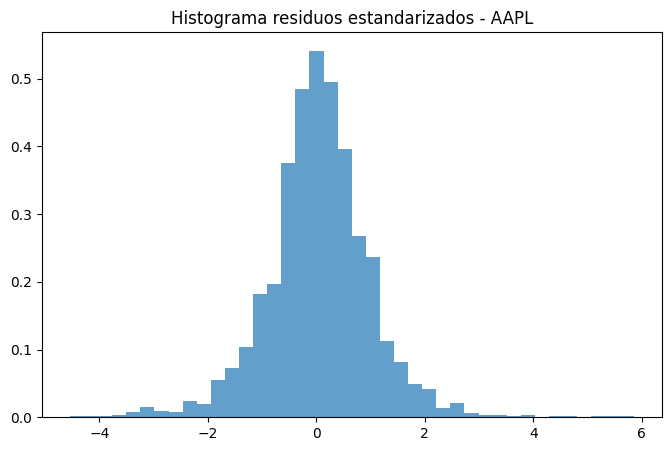

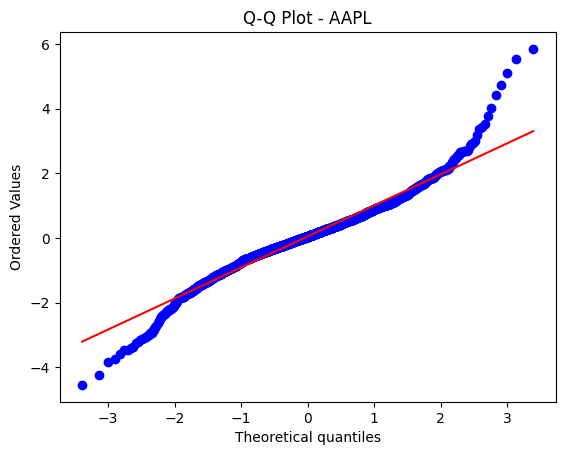

SignificanceResult(statistic=np.float64(922.0785543511939), pvalue=np.float64(5.931792928946061e-201))


In [99]:
plt.figure(figsize=(8,5))
plt.hist(residuos_aapl, bins=40, density=True, alpha=0.7)
plt.title("Histograma residuos estandarizados - AAPL")
plt.show()

stats.probplot(residuos_aapl, dist="norm", plot=plt)
plt.title("Q-Q Plot - AAPL")
plt.show()

jb_aapl = jarque_bera(residuos_aapl)

print(jb_aapl)

# BTC-USD

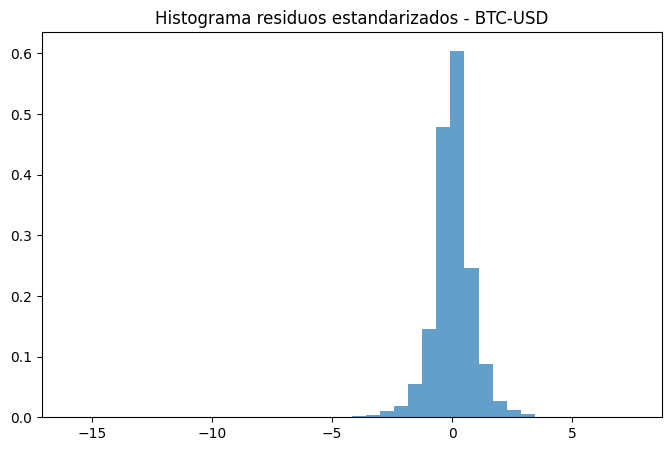

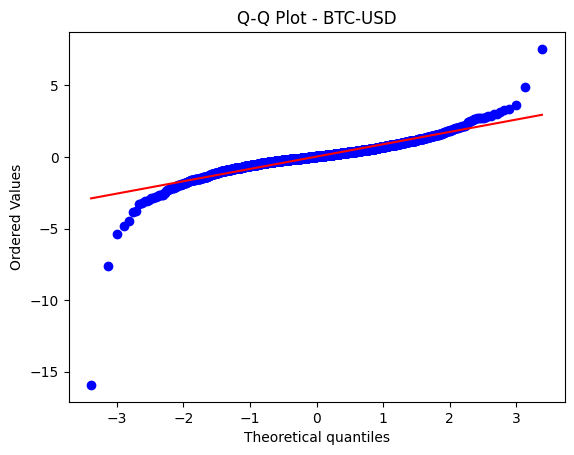

SignificanceResult(statistic=np.float64(182251.1920703138), pvalue=np.float64(0.0))


In [100]:
plt.figure(figsize=(8,5))
plt.hist(residuos_btc, bins=40, density=True, alpha=0.7)
plt.title("Histograma residuos estandarizados - BTC-USD")
plt.show()

stats.probplot(residuos_btc, dist="norm", plot=plt)
plt.title("Q-Q Plot - BTC-USD")
plt.show()

jb_btc = jarque_bera(residuos_btc)

print(jb_btc)

In [101]:
print("AAPL:", jarque_bera(residuos_aapl))
print("BTC-USD:", jarque_bera(residuos_btc))

AAPL: SignificanceResult(statistic=np.float64(922.0785543511939), pvalue=np.float64(5.931792928946061e-201))
BTC-USD: SignificanceResult(statistic=np.float64(182251.1920703138), pvalue=np.float64(0.0))


Los modelos seleccionados representan adecuadamente la volatilidad de AAPL y BTC-USD.

Los residuos no presentan autocorrelación importante ni efectos ARCH residuales, según los resultados de los tests de Ljung-Box y ARCH-LM.

Sin embargo, el test de Jarque-Bera muestra que los residuos no siguen una distribución normal, ya que presentan colas más pesadas.

En conjunto, los resultados indican que los modelos capturan bien la dinámica de la volatilidad, aunque todavía existen algunos valores extremos característicos de los mercados financieros.

# Pronóstico y Gestión de Riesgo: Value-at-Risk

## Pronóstico de Volatilidad